# Load the preprocessed data

In [12]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
import os


In [13]:
# Loading the TF-IDF features and target labels
load = joblib.load
X_train = load("../data/saved_features/X_train_tfidf.joblib")
X_test = load("../data/saved_features/X_test_tfidf.joblib")
y_train = load("../data/saved_features/y_train.joblib")
y_test = load("../data/saved_features/y_test.joblib")

# Random Forest Traning

In [14]:
def train_random_forest(X_train, y_train, n_estimators = 100, random_state = 42):
    print("Traning Random Forest on CPU (using all cores)")
    rf_model = RandomForestClassifier(n_estimators = n_estimators, random_state = random_state, n_jobs = -1)
    rf_model.fit(X_train, y_train)
    print("Random Forest traning complete.")
    return rf_model

# XGBoost Traning 

In [15]:
import xgboost as xgb
import numpy as np

def train_xgboost(X_train, y_train, n_estimators = 100, learning_rate = 0.1, random_state = 42):
    print("Training XGBoost on GPU (RTX 4060)")

    xgb_model = XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=random_state,
        tree_method='hist',
        device='cuda',
        objective='binary:logistic',
        eval_metric='logloss'
    )

    print("Fitting model.....")
    # Fit directly (XGBoost handles the DMatrix conversion internally)
    xgb_model.fit(X_train, y_train)
    print("XGBoost training complete.")

    return xgb_model

# Save the models (The weights)

In [16]:
def save_model(model, filename, save_dir = "../results/models/"):
    os.makedirs(save_dir, exist_ok = True)
    file_path = os.path.join(save_dir, filename)
    joblib.dump(model, file_path)
    print(f"Model saved successfully to {file_path}")

# Running all the methods

In [17]:
# rf = train_random_forest(X_train, y_train)
# xgb_model = train_xgboost(X_train, y_train)
# save_model(rf,"rf")
# save_model(xgb_model,"xgb")
rf = joblib.load("../results/models/rf")
xgb_model = joblib.load("../results/models/xgb")

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

def plot_confusion_matrix(y_true, y_pred, model_name, save_dir = "../results/figures/"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize = (6, 4))
    sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = False)

    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted Label (0 = Real, 1 = Fake)")
    plt.ylabel("True Label (0 = Real, 1 = Fake)")

    os.makedirs(save_dir, exist_ok = True)
    file_path = os.path.join(save_dir, f"{model_name}_confusion_matrix.png")
    plt.savefig(file_path, bbox_inches = 'tight')
    plt.show()
    print(f"Confusion matrix saved to {file_path}")

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

def evaluate_model(model, X_test, y_test, model_name):
    print(f"--- Evaluating {model_name} ---")
    
    # Generate predictions
    if isinstance(model, xgb.XGBClassifier):
        # Convert to DMatrix on GPU for XGBoost to avoid warning and speed up
        dtest = xgb.DMatrix(X_test)
        # Model returns probabilities, get hard predictions (threshold = 0.5)
        y_prob = model.get_booster().predict(dtest)
        y_pred = (y_prob > 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}\n")
    
    # Full classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 40 + "\n")

    return y_pred

--- Evaluating Random Forest ---
Accuracy: 0.7704

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78    149933
           1       0.77      0.75      0.76    146505

    accuracy                           0.77    296438
   macro avg       0.77      0.77      0.77    296438
weighted avg       0.77      0.77      0.77    296438

Confusion Matrix:
[[117759  32174]
 [ 35897 110608]]
----------------------------------------



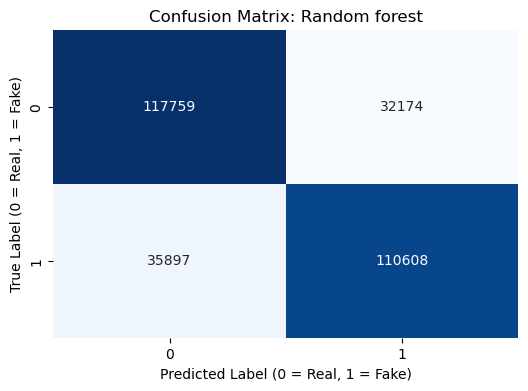

Confusion matrix saved to ../results/figures/Random forest_confusion_matrix.png
--- Evaluating XGBoost ---
Accuracy: 0.5104

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.03      0.07    149933
           1       0.50      1.00      0.67    146505

    accuracy                           0.51    296438
   macro avg       0.73      0.52      0.37    296438
weighted avg       0.73      0.51      0.36    296438

Confusion Matrix:
[[  5073 144860]
 [   269 146236]]
----------------------------------------



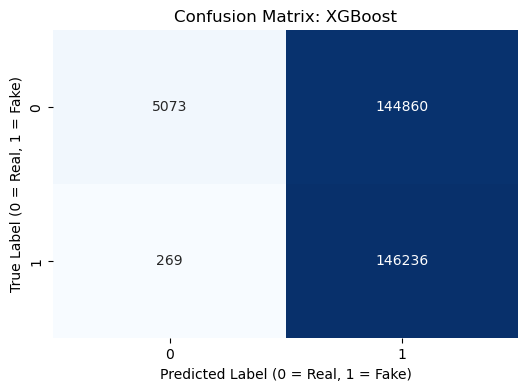

Confusion matrix saved to ../results/figures/XGBoost_confusion_matrix.png


In [20]:
# Evaluate Random Forest
y_pred = evaluate_model(rf, X_test, y_test, "Random Forest")
plot_confusion_matrix(y_test, y_pred, "Random forest", save_dir = "../results/figures/")


# Evaluate XGBoost
y_pred = evaluate_model(xgb_model, X_test, y_test, "XGBoost")
plot_confusion_matrix(y_test, y_pred, "XGBoost", save_dir = "../results/figures/")


In [ ]:
from sklearn.decomposition import TruncatedSVD
import joblib
import os

def apply_truncated_svd(X_train, X_test, n_components = 500, random_state = 42):
    print(f"Applying Truncated SVD to reduce features to {n_components} components...")

    svd = TruncatedSVD(n_components = n_components, random_state = random_state)

    X_train_svd = svd.fit_transform(X_train)
    X_test_svd = svd.transform(X_test)

    explained_variance = svd.explained_variance_ratio_.sum() * 100
    print(f"Total variance explained by {n_components} components: {explained_variance: .2f}%")

    return X_train_svd, X_test_svd, svd

def save_svd_features(X_train_svd, X_test_svd, svd_model, save_dir = "../data/saved_features/"):
    os.makedirs(save_dir, exist_ok = True)
    joblib.dump(X_train_svd, os.path.join(save_dir, "X_train_svd.joblib"))
    joblib.dump(X_test_svd, os.path.join(save_dir, "X_test_svd.joblib"))
    joblib.dump(svd_model, os.path.join(save_dir, "svd_model.joblib"))
    print("SVD features and model saved successfully.")